In [1]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
insurance_data=pd.read_csv("insurance_csv.csv")

In [3]:
x=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]
x=pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)

In [4]:
x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes":1,"no":0})
x["age_smoker"]=x["age"]*x["smoker"]
x["bmi_smoker"]=x["bmi"]*x["smoker"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


20922599.87103596
20921803.698431373
20914832.635089133
20908106.77995452
20890881.000633497
20872844.794796687
20877828.53237883
20937537.133939777
21046489.29389078
21196929.869608905
22423172.686023258


<Axes: >

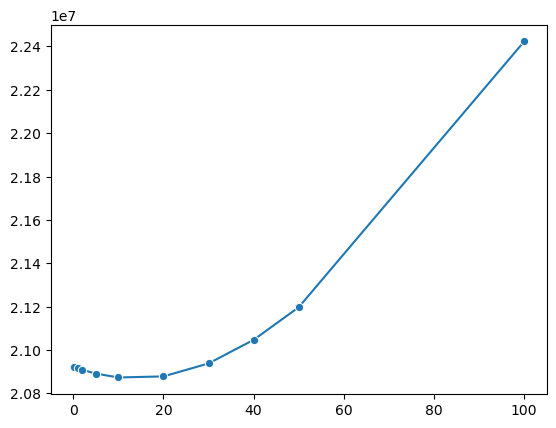

In [5]:
from sklearn.metrics import mean_squared_error
import seaborn as sns
from sklearn.linear_model import Lasso
alphas=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mses=[]
for a in alphas:
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(x_train,y_train)
    y_pred=lasso_model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    print(mse)
    mses.append(mse)
sns.lineplot(x=alphas,y=mses,marker="o")

In [6]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error,r2_score
a=[0.0001,0.1,1,2,5,10,20,30,40,50,100]
lasso_cv_model=LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=42)
lasso_cv_model.fit(x_train,y_train)
print(lasso_cv_model.alpha_)
y_pred=lasso_cv_model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(mse)
print(r2)


0.0001
20922607.131011523
0.8652317031516603


In [7]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score

In [8]:
df=pd.read_csv("heart.csv")
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [9]:
x=df.drop("target",axis=1)
y=df["target"]
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train[x_train==1]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,NaN,1.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
202,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
196,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN
75,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
176,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN
71,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN
106,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN
270,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:

model=LogisticRegression(max_iter=2000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("accuracy score:",accuracy_score(y_test,y_pred)*100,"%")
print("precision:",precision_score(y_test,y_pred)*100,"%")

accuracy score: 88.52459016393442 %
precision: 87.87878787878788 %


In [12]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[25  4]
 [ 3 29]]


In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [14]:
import pandas as pd
from sklearn.metrics import precision_score,accuracy_score,recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


In [15]:
df=pd.read_csv("heart.csv")

In [16]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [17]:
x=df.drop("target",axis=1)
y=df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [18]:
gnb_model=GaussianNB()
gnb_model.fit(x_train,y_train)
y_pred=gnb_model.predict(x_test)

In [19]:
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))

recall score: 0.84375
accuracy score: 0.8688524590163934
precision score: 0.9


In [20]:
import pandas as pd
from sklearn.metrics import precision_score,accuracy_score,recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


In [21]:
df=pd.read_csv("heart.csv")
df


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [22]:
x=df.drop("target",axis=1)
y=df["target"]


In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [25]:
from sklearn.model_selection import GridSearchCV
classifier=KNeighborsClassifier()
param_grid={"n_neighbors":[3,5,7,9]}
classifierCV=GridSearchCV(
    classifier,
    param_grid,
    cv=5)
classifierCV.fit(x_train_scaled,y_train)
y_pred=classifierCV.predict(x_test_scaled)


In [26]:
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
results=pd.DataFrame(classifierCV.cv_results_)
print(results[["param_n_neighbors","mean_test_score"]])
print(classifierCV.best_params_)

recall score: 0.875
accuracy score: 0.9016393442622951
precision score: 0.9333333333333333
   param_n_neighbors  mean_test_score
0                  3         0.805782
1                  5         0.814116
2                  7         0.801616
3                  9         0.801786
{'n_neighbors': 5}


In [27]:
from sklearn.pipeline import Pipeline
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
pipe=Pipeline([("scaler",StandardScaler()),
                   ("knn",KNeighborsClassifier())])
param_grid={"knn__n_neighbors":[3,5,7,9]}
classifierCV=GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="recall")
classifierCV.fit(x_train,y_train)
y_pred=classifierCV.predict(x_test)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print(classifierCV.best_params_)



recall score: 0.90625
accuracy score: 0.9180327868852459
precision score: 0.9354838709677419
{'knn__n_neighbors': 7}


In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [29]:
df=pd.read_csv("loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [30]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["number"]).columns

In [31]:
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [32]:
df.head()


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


[Text(0, 0, '621'), Text(0, 0, '379')]

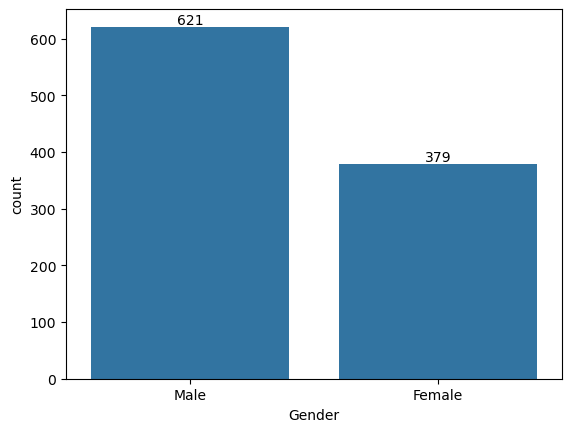

In [33]:
gender_cnt=df["Gender"].value_counts()
ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])


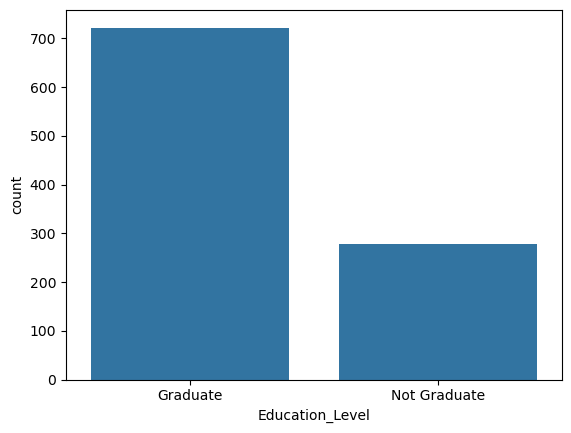

In [34]:
edu_dnt=df["Education_Level"].value_counts()
ax=sns.barplot(edu_dnt)


<Axes: xlabel='Applicant_Income', ylabel='Count'>

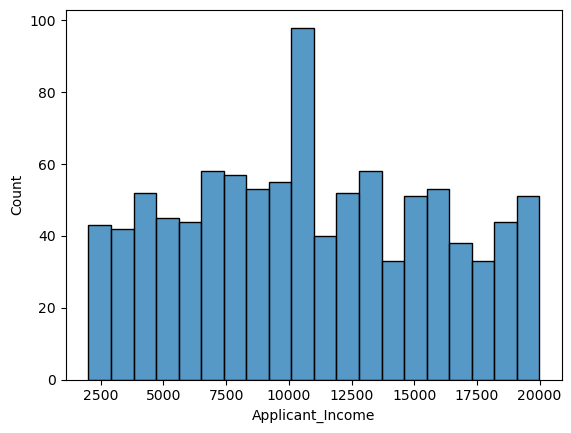

In [35]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

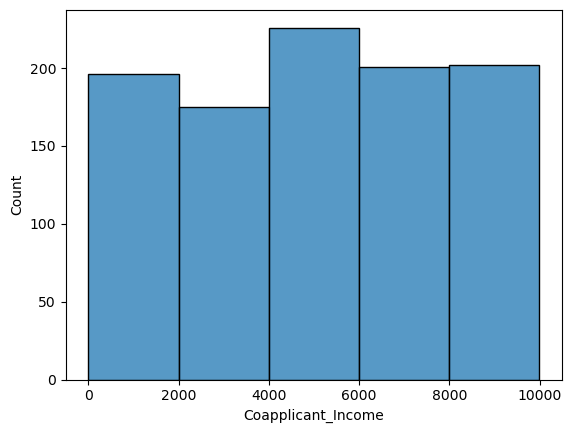

In [36]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=5)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

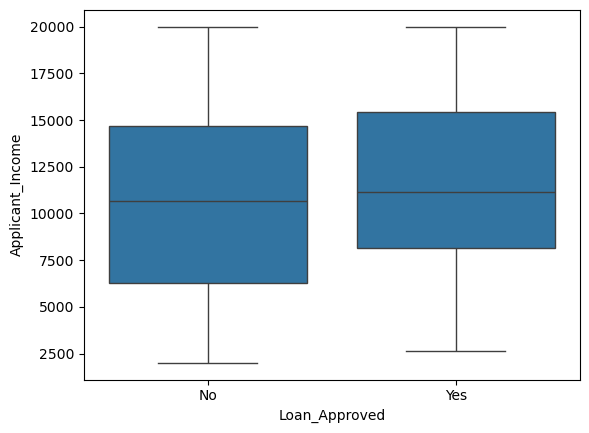

In [37]:
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income")

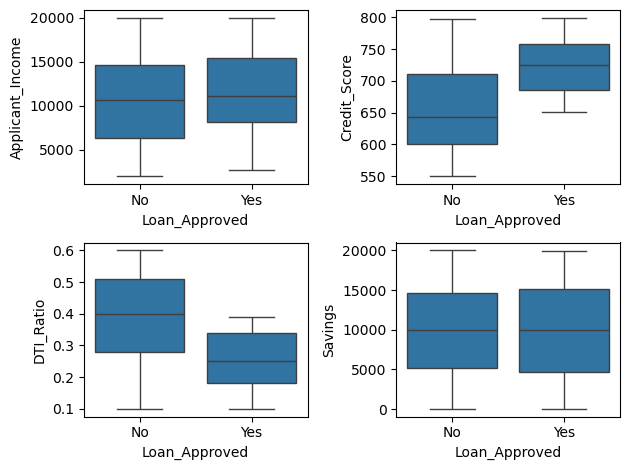

In [38]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

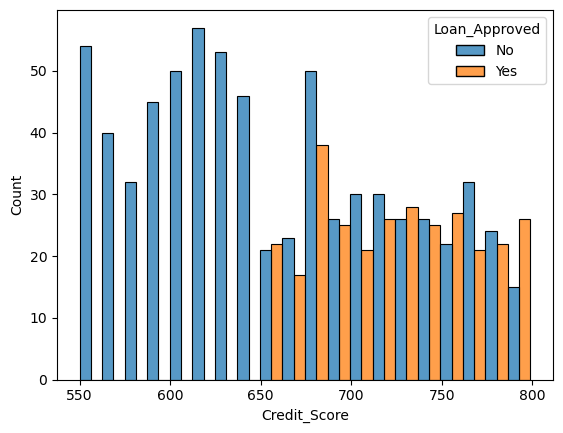

In [39]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [40]:
df=df.drop("Applicant_ID",axis=1)
df.head()


,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [41]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df.head()
df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [42]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
one=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=one.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=one.get_feature_names_out(cols),index=df.index)

In [43]:
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [44]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


<Axes: >

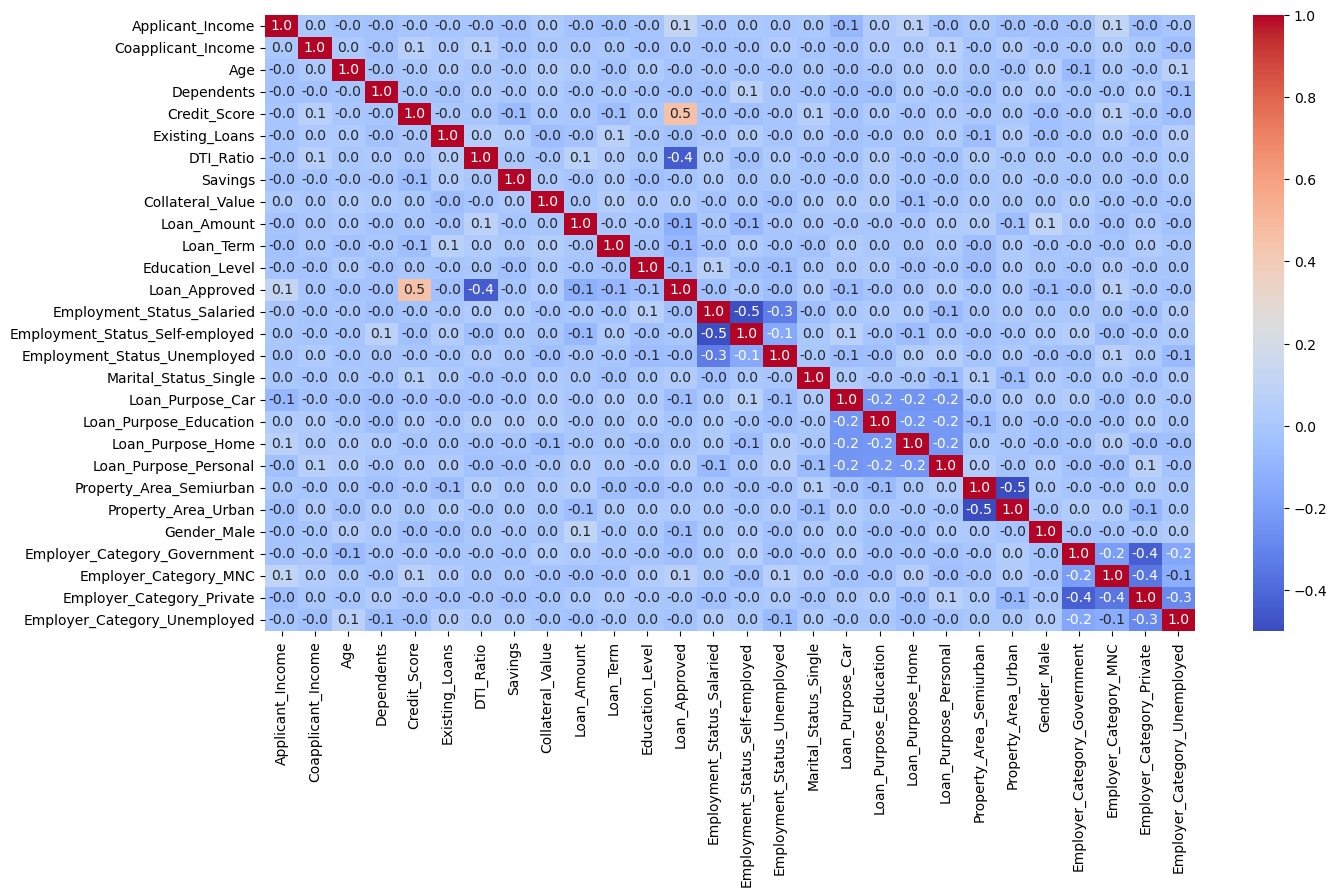

In [45]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".1f",
    cmap="coolwarm")



In [46]:
num_cols.corr()["Loan_Approved"]


Applicant_Income                   0.119796
Coapplicant_Income                 0.004230
Age                               -0.022343
Dependents                        -0.023811
Credit_Score                       0.451175
Existing_Loans                    -0.034794
DTI_Ratio                         -0.444783
Savings                           -0.013437
Collateral_Value                   0.021868
Loan_Amount                       -0.126499
Loan_Term                         -0.086644
Education_Level                   -0.052920
Loan_Approved                      1.000000
Employment_Status_Salaried        -0.041428
Employment_Status_Self-employed   -0.001337
Employment_Status_Unemployed      -0.044464
Marital_Status_Single              0.030182
Loan_Purpose_Car                  -0.056416
Loan_Purpose_Education            -0.016684
Loan_Purpose_Home                  0.002118
Loan_Purpose_Personal              0.034043
Property_Area_Semiurban           -0.012967
Property_Area_Urban             

In [47]:
x=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]


In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_test.head()


,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
521,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,22947.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,20522.825263,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
740,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,5876.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
660,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,8433.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
411,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,33926.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [49]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))

recall score: 0.7704918032786885
accuracy score: 0.865
precision score: 0.7833333333333333
cm: [[126  13]
 [ 14  47]]


In [51]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=19)
knn.fit(x_train_scaled,y_train)
y_pred=knn.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))

recall score: 0.4098360655737705
accuracy score: 0.77
precision score: 0.7142857142857143
cm: [[129  10]
 [ 36  25]]


In [52]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred=nb_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))


recall score: 0.7377049180327869
accuracy score: 0.865
precision score: 0.8035714285714286
cm: [[128  11]
 [ 16  45]]


In [53]:
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
df["Credit_Score_sq"]=df["Credit_Score"]**2

In [54]:
x=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y=df["Loan_Approved"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)



In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(x_train_scaled,y_train)
y_pred=log_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))

recall score: 0.8032786885245902
accuracy score: 0.875
precision score: 0.7903225806451613
cm: [[126  13]
 [ 12  49]]


In [56]:


from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=19)
knn.fit(x_train_scaled,y_train)
y_pred=knn.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))


recall score: 0.4262295081967213
accuracy score: 0.79
precision score: 0.7878787878787878
cm: [[132   7]
 [ 35  26]]


In [57]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred=nb_model.predict(x_test_scaled)
print("recall score:",recall_score(y_test,y_pred))
print("accuracy score:",accuracy_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("cm:",confusion_matrix(y_test,y_pred))


recall score: 0.7704918032786885
accuracy score: 0.865
precision score: 0.7833333333333333
cm: [[126  13]
 [ 14  47]]


In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [59]:
tit=sns.load_dataset("titanic")

In [60]:
tit.head()
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [61]:
tit.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [62]:
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
tit["age"]=imp_median.fit_transform(tit[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
tit["embarked"]=imp_freq.fit_transform(tit[["embarked"]]).ravel()

In [63]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
tit["sex"]=le.fit_transform(tit["sex"])
tit["embarked"]=le.fit_transform(tit["embarked"])

In [64]:
x=tit[features]
y=tit[target]

In [65]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [66]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test)
print("accuracy score:",(y_test,y_pred))

accuracy score: (     survived
709         1
439         0
840         0
720         1
39          1
..        ...
433         0
773         0
25          1
84          1
10          1

[179 rows x 1 columns], array([0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1]))


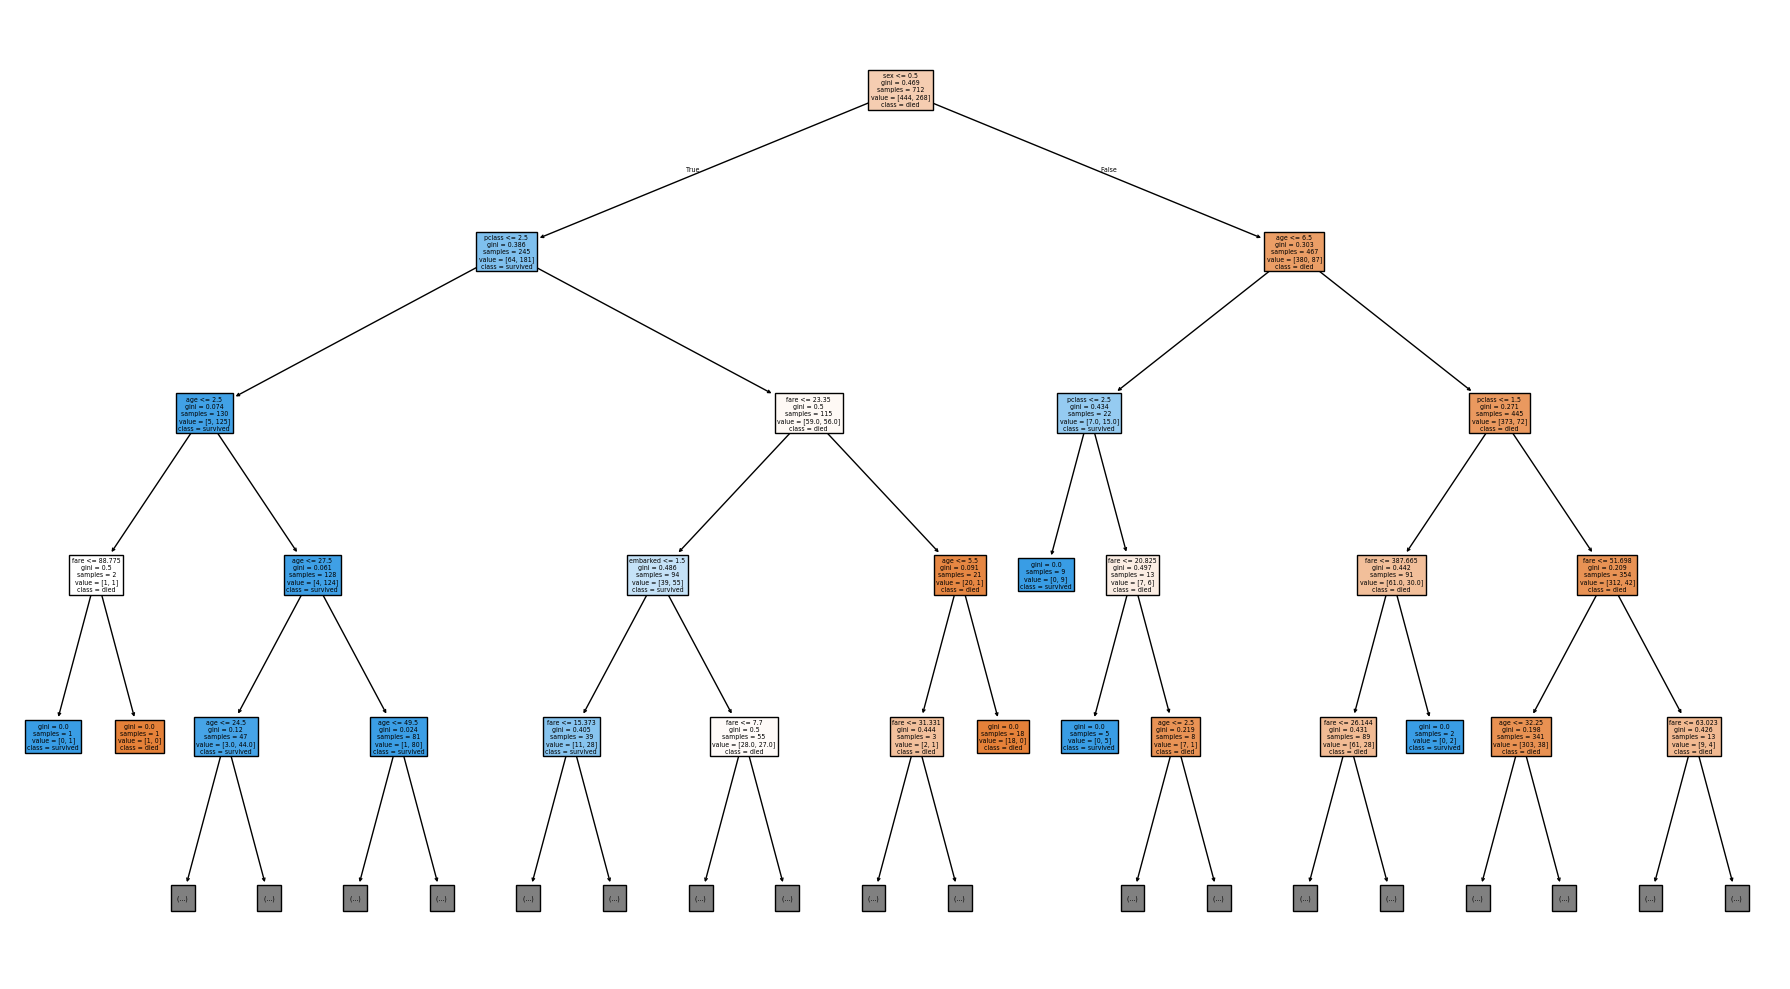

In [67]:
from  sklearn.tree import plot_tree
plt.figure(figsize =(18,10)),
plot_tree(model,
          feature_names=x.columns,
          class_names=["died","survived"],
          filled=True,
          max_depth=4)
plt.tight_layout()
plt.show()
          

 for depth=2,accuracy=0.7653631284916201
 for depth=3,accuracy=0.7988826815642458
 for depth=4,accuracy=0.7988826815642458
 for depth=5,accuracy=0.7988826815642458
 for depth=6,accuracy=0.7988826815642458
 for depth=7,accuracy=0.7988826815642458
 for depth=8,accuracy=0.7877094972067039
 for depth=9,accuracy=0.7932960893854749
 for depth=10,accuracy=0.7932960893854749


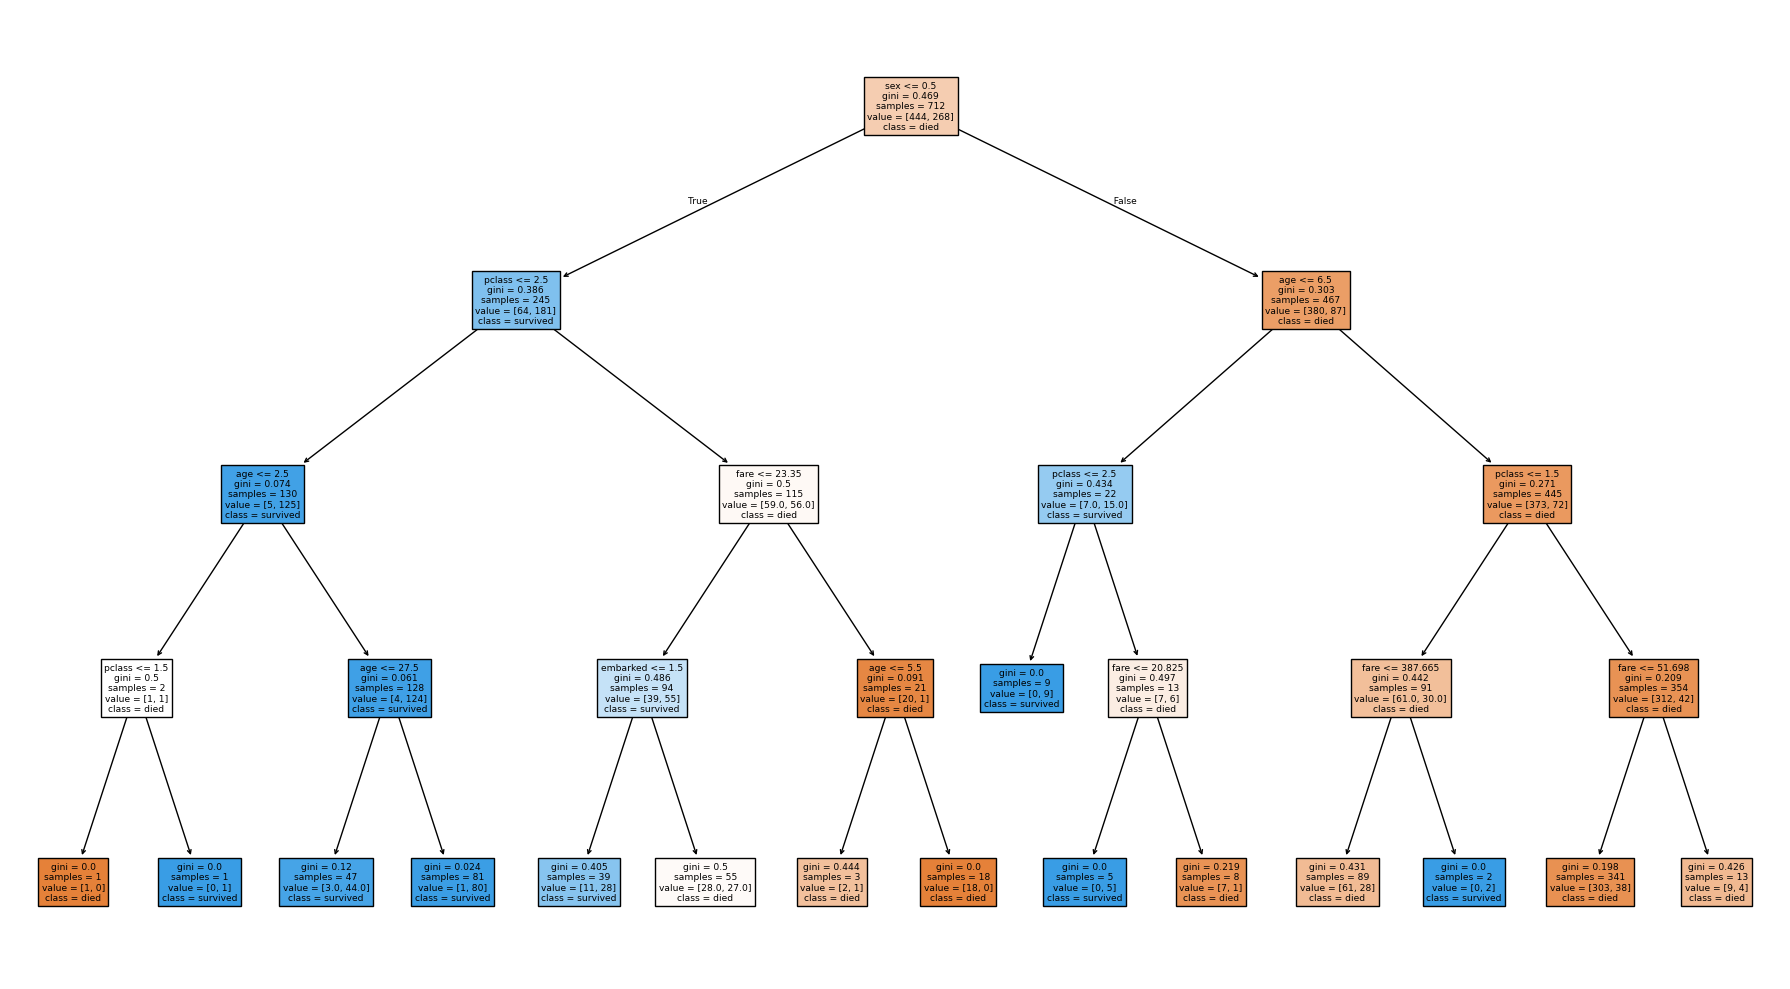

In [68]:
max_depths=[2,3,4,5,6,7,8,9,10]
for depth in max_depths:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f" for depth={depth},accuracy={acc}")
    if depth==4:
       plt.figure(figsize=(18,10)),
       plot_tree(model,
              feature_names=x.columns,
              class_names=["died","survived"],
      filled=True)
plt.tight_layout()
plt.show()


for sample split=5,accuracy=0.7988826815642458
for sample split=10,accuracy=0.7988826815642458


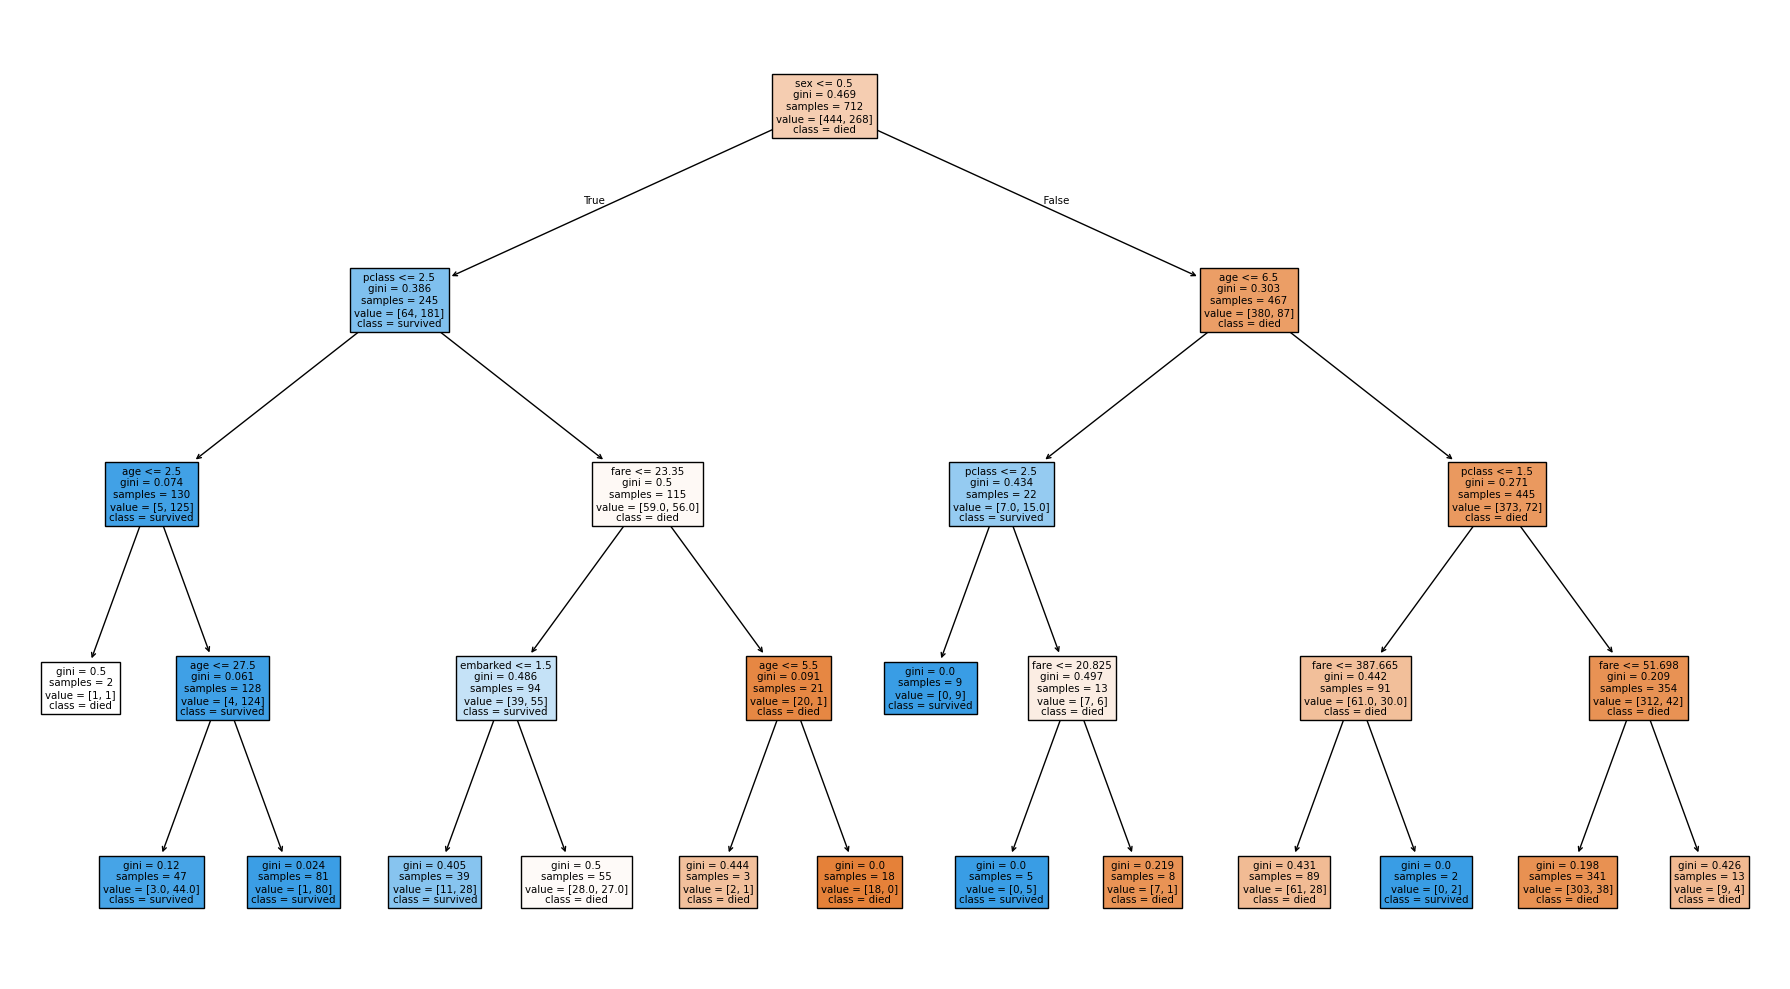

for sample split=15,accuracy=0.7988826815642458
for sample split=20,accuracy=0.7988826815642458
for sample split=25,accuracy=0.7932960893854749
for sample split=30,accuracy=0.7932960893854749


In [69]:
min_samples_split=[5,10,15,20,25,30]
for split in min_samples_split:
    model=DecisionTreeClassifier(max_depth=4,
                                 min_samples_split=split)
    model.fit(x_train,y_train)
    acc=model.score(x_test,y_test)
    print(f"for sample split={split},accuracy={acc}")
    if split==10:
        plt.figure(figsize=(18,10))
        plot_tree(model,
        feature_names=x.columns,
        class_names=["died","survived"],
        filled=True)
        plt.tight_layout()
        plt.show()

In [70]:
full_tree=DecisionTreeClassifier(random_state=42)

In [71]:
full_tree.fit(x_train,y_train)
path=full_tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [72]:
trees=[]
for alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(x_train,y_train)
    trees.append((model,alpha))
    best_acc=0
    best_alpha=0
    for model,alpha in trees:
        curr_acc=model.score(x_test,y_test)
        if curr_acc>best_acc:
            best_acc=curr_acc
            best_alpha=alpha
    

In [73]:
best_acc

0.8379888268156425

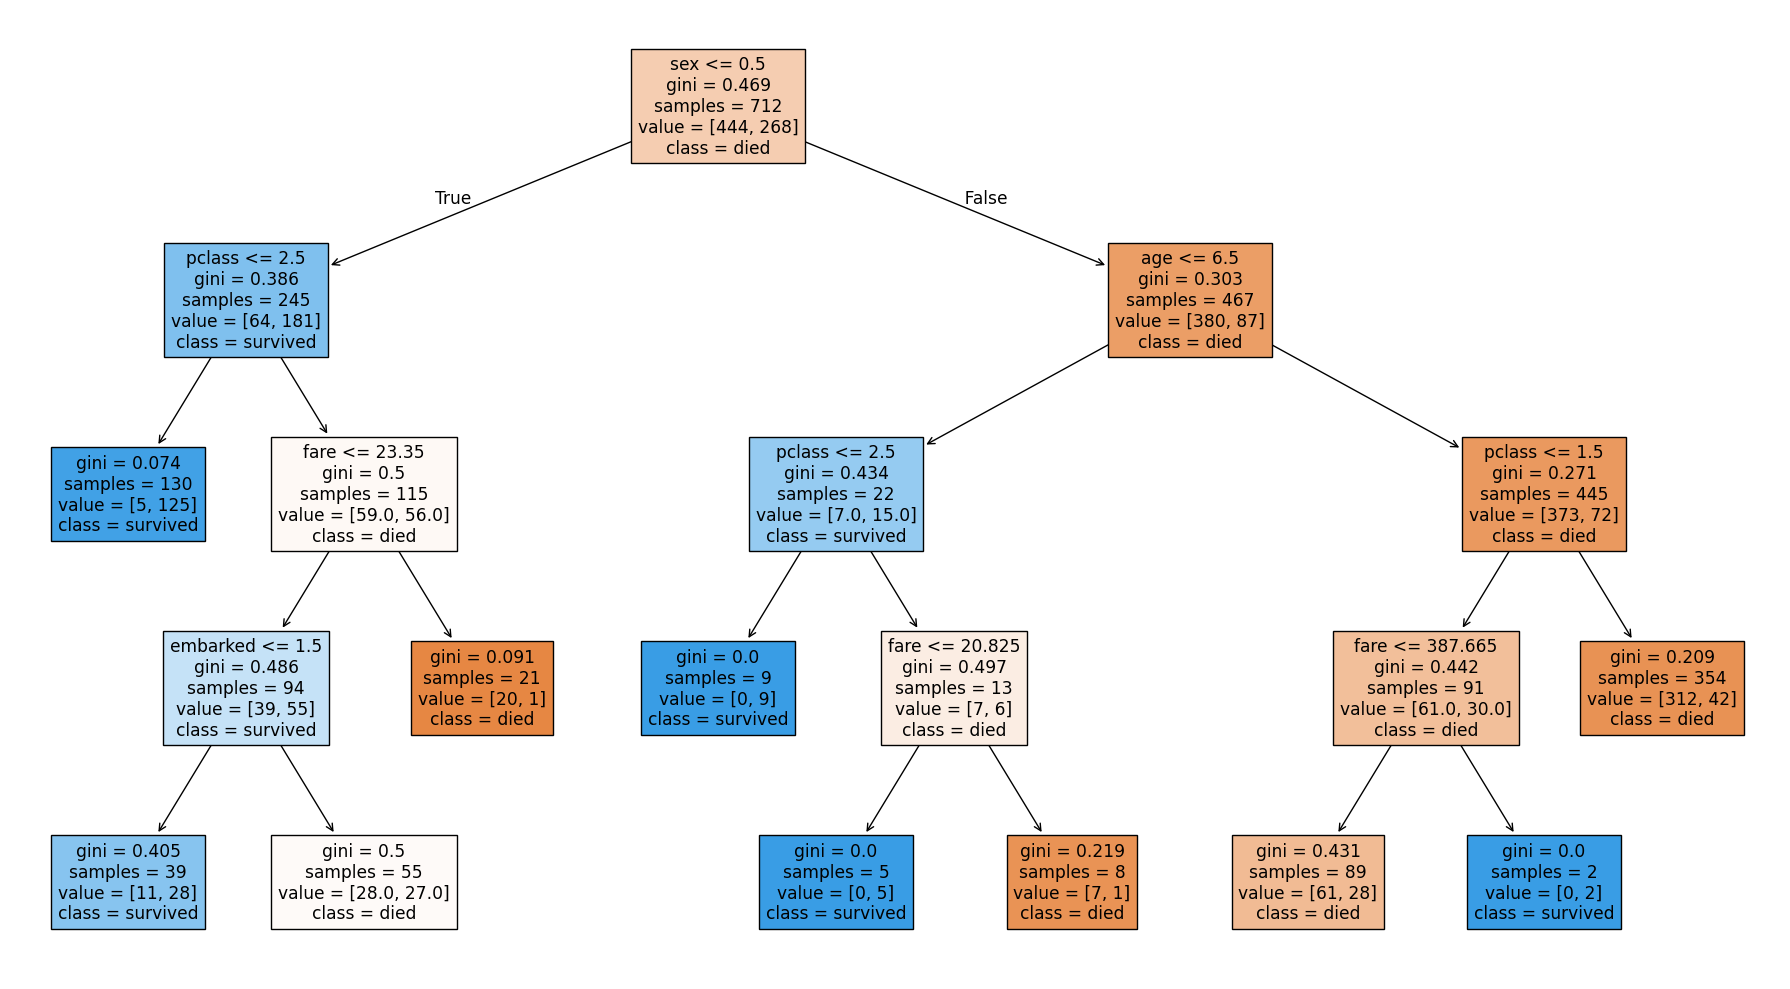

In [74]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha,max_depth=4)
best_model.fit(x_train,y_train)
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=["died","survived"],
    filled=True)
plt.tight_layout()
plt.show()


In [75]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
df=load_diabetes(as_frame=True).frame
x=df.drop("target",axis=1)
y=df["target"]


In [76]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(max_depth=7,min_samples_leaf=20)
model.fit(x_train,y_train)
from sklearn.metrics import r2_score,mean_squared_error
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)
print("MSE train:",(y_train,y_pred_train))
print("MSE test:",(y_test,y_pred_test))

MSE train: (225    208.0
412    261.0
118    179.0
114    258.0
364    262.0
       ...  
106    134.0
270    202.0
348    148.0
435     64.0
102    302.0
Name: target, Length: 309, dtype: float64, array([226.22857143, 271.12      , 183.36      , 271.12      ,
       183.36      ,  88.42857143, 271.12      ,  88.86363636,
       226.22857143, 175.52173913, 109.23809524, 175.52173913,
       226.22857143, 144.85      , 175.52173913, 183.36      ,
       144.85      , 187.7826087 , 271.12      , 187.7826087 ,
       183.36      ,  68.05      , 183.36      , 142.25      ,
        88.42857143, 144.85      ,  88.42857143, 144.85      ,
        68.05      ,  88.86363636, 144.05      , 144.05      ,
       183.36      , 187.7826087 ,  88.86363636, 109.23809524,
        88.42857143, 144.85      , 129.6       , 129.6       ,
       226.22857143, 226.22857143, 183.36      , 271.12      ,
       226.22857143, 226.22857143, 144.05      ,  88.42857143,
       187.7826087 , 144.05      ,  68.05     

In [77]:
print("r2 train:",r2_score(y_train,y_pred_train))
print("r2 test:",r2_score(y_test,y_pred_test))

r2 train: 0.5452860742356658
r2 test: 0.41135906558189406


In [78]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn import datasets

In [79]:
df=datasets.load_iris(as_frame=True).frame

In [80]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [81]:
df.shape

(150, 5)

In [82]:
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [83]:
x=df.drop("target",axis=1)
y=df["target"]

In [84]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [85]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [86]:
svc=SVC()
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)


In [87]:
from sklearn.metrics import accuracy_score,classification_report
print("accuracy:",accuracy_score(y_test,y_pred))
print("classification report:",classification_report(y_test,y_pred))

accuracy: 0.9666666666666667
classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [88]:
svc=SVC(kernel="linear")
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 1.0


In [89]:
svc=SVC(kernel="poly")
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)
print("accuracy score:",accuracy_score(y_test,y_pred))

accuracy score: 0.9


In [90]:
svc=SVC(kernel="sigmoid")
svc.fit(x_train_scaled,y_train)
y_pred=svc.predict(x_test_scaled)
print("accuracy score:",accuracy_score(y_test,y_pred))


accuracy score: 0.9


In [91]:
c_vals=[0.5,1,2,3,4,5]
for c_val in c_vals:
    svc=SVC(C=c_val,kernel="rbf")
    svc.fit(x_train_scaled,y_train)
    y_pred=svc.predict(x_test_scaled)
    print("c= ",c_val,"& accuracy_score:",accuracy_score(y_test,y_pred))

c=  0.5 & accuracy_score: 0.9666666666666667
c=  1 & accuracy_score: 0.9666666666666667
c=  2 & accuracy_score: 0.9333333333333333
c=  3 & accuracy_score: 0.9666666666666667
c=  4 & accuracy_score: 0.9666666666666667
c=  5 & accuracy_score: 0.9666666666666667


In [92]:
from sklearn.svm import SVR
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn import datasets

In [93]:
df=datasets.load_diabetes(as_frame=True).frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [94]:
x=df.drop("target",axis=1)
y=df["target"]

In [95]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [96]:
y_scaler=StandardScaler()
y_train_scaled=y_scaler.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_scaled=y_scaler.transform(y_test.values.reshape(-1,1)).ravel()

In [97]:
model=SVR()
model.fit(x_train,y_train_scaled)
y_test_pred=model.predict(x_test)
y_train_pred=model.predict(x_train)

In [98]:
print("train r2:",r2_score(y_train_scaled,y_train_pred))
print("test r2:",r2_score(y_test_scaled,y_test_pred))


train r2: 0.6546589086413884
test r2: 0.5235758823629255


In [100]:
model=SVR(kernel="rbf")
model.fit(x_train,y_train_scaled)
y_test_pred=model.predict(x_test)
y_train_pred=model.predict(x_train)
print("train r2:",r2_score(y_train_scaled,y_train_pred))
print("test r2:",r2_score(y_test_scaled,y_test_pred))


train r2: 0.6546589086413884
test r2: 0.5235758823629255


In [101]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "C":[1,2,5,10,50,100],
    "kernel":["rbf","linear"],
    "epsilon":[0.01,0.1,0.2,0.3,0.5]}
svr=SVR()
grid_search=GridSearchCV(svr,param_grid,scoring="r2",cv=5)
grid_search.fit(x_train,y_train_scaled)
print("best params_",grid_search.best_params_)


best params_ {'C': 5, 'epsilon': 0.1, 'kernel': 'linear'}


In [102]:
best_model=SVR(kernel="linear",C=10,epsilon=0.1)
best_model.fit(x_train,y_train_scaled)
y_pred_test=best_model.predict(x_test)
y_pred_train=best_model.predict(x_train)
print("train r2:",r2_score(y_train_scaled,y_pred_train))
print("test r2:",r2_score(y_test_scaled,y_pred_test))

train r2: 0.5194566808903602
test r2: 0.4579035279419059


In [103]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [104]:
titanic=sns.load_dataset("titanic")
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [105]:
imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [106]:
le=LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [107]:
x=titanic[features]
y=titanic["survived"]

In [108]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [109]:
model=DecisionTreeClassifier(max_depth=4)
model.fit(x_train,y_train)
y_pred_test=model.predict(x_test)
y_pred_train=model.predict(x_train)
print("training accuracy:",accuracy_score(y_train,y_pred_train)*100,"%")
print("testing accuracy:",accuracy_score(y_test,y_pred_test)*100,"%")

training accuracy: 83.98876404494382 %
testing accuracy: 79.88826815642457 %


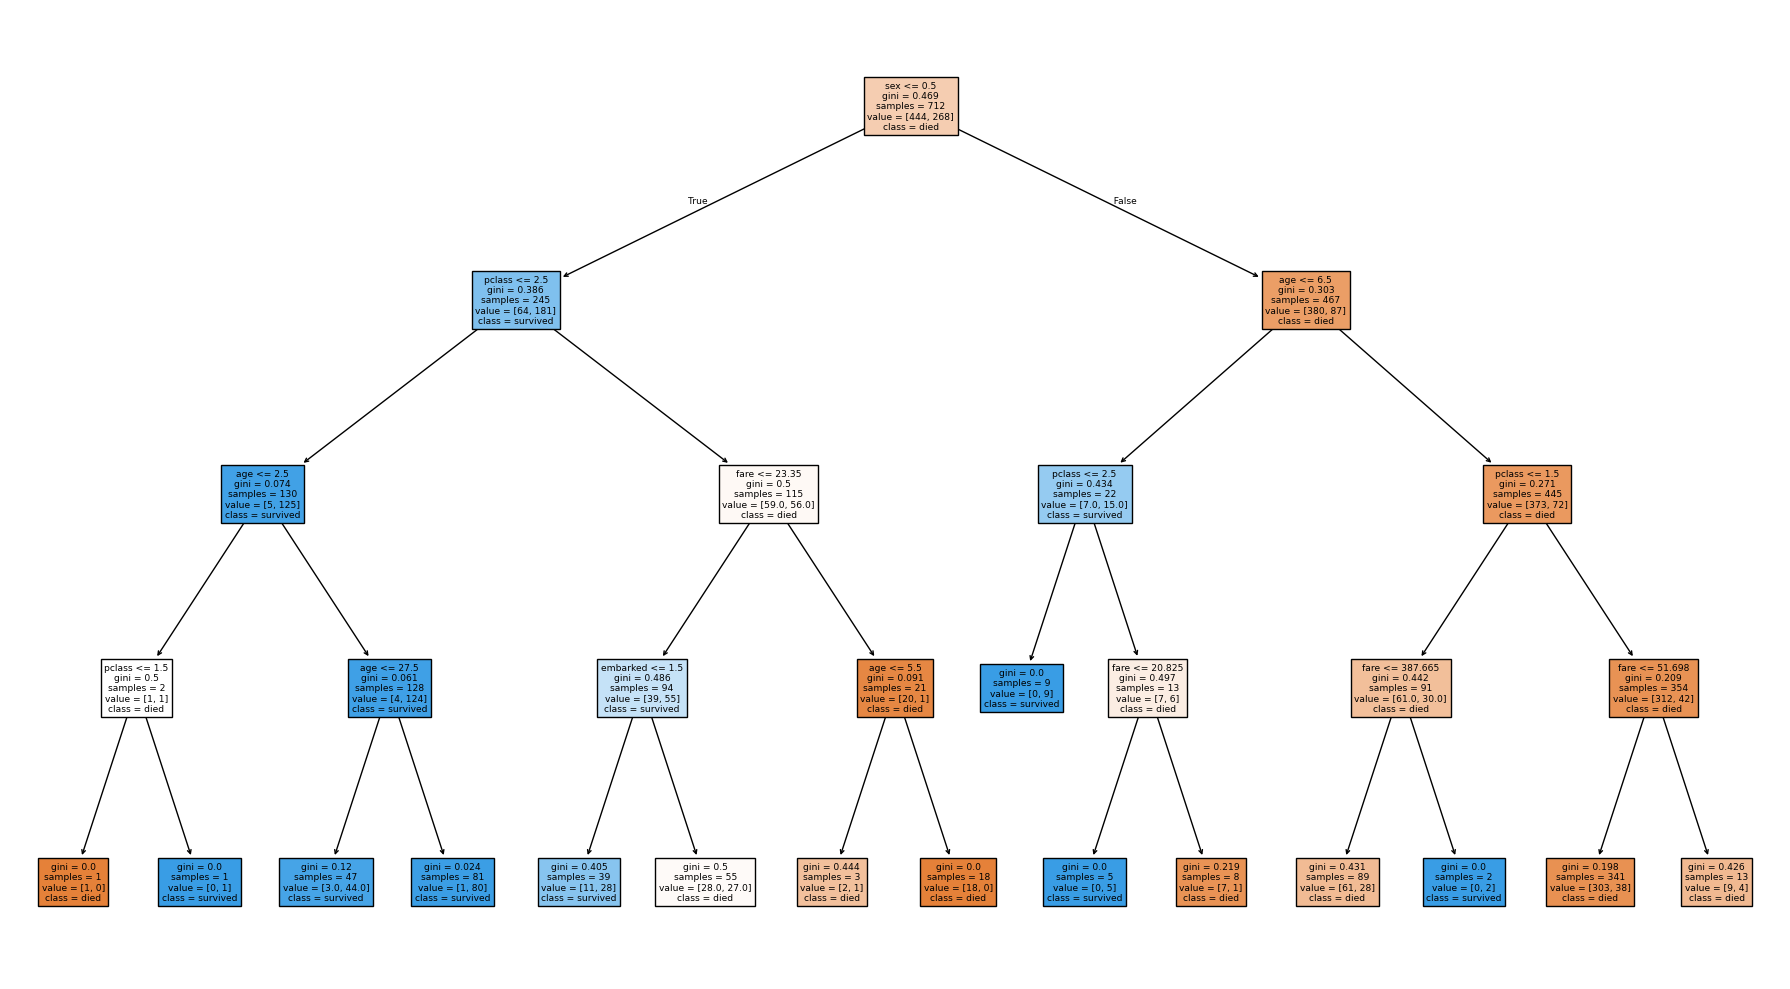

In [110]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(model,
          feature_names=x.columns,
          class_names=["died","survived"],
          filled=True)
plt.tight_layout()

In [111]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    max_depth=4)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print("oob score:",rf.oob_score_*100,"%")
print("testing accuracy:",accuracy_score(y_test,y_pred))


oob score: 82.7247191011236 %
testing accuracy: 0.8156424581005587


In [112]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
base_model=LogisticRegression(max_iter=1000)
bagging=BaggingClassifier(base_model,
                          n_estimators=201)
bagging.fit(x_train,y_train)
y_pred=bagging.predict(x_test)
print("accuracy socre:",accuracy_score(y_test,y_pred))

accuracy socre: 0.7988826815642458


In [113]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

In [114]:
x,y=make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    random_state=42)

In [115]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [116]:
from sklearn.ensemble import GradientBoostingClassifier
gbr=GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42)
gbr.fit(x_train,y_train)
y_pred=gbr.predict(x_test)
print("acdcuracy score:",accuracy_score(y_test,y_pred))

acdcuracy score: 0.9


In [117]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.tree import DecisionTreeClassifier


In [118]:
make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    random_state=42)


(array([[ 0.63775562,  1.14520678, -3.74192422, ..., -0.06327396,
         -0.65974864, -0.70468412],
        [-2.49065159, -0.48548658, -2.38264783, ..., -1.30777657,
         -0.3451041 , -0.30856506],
        [ 1.13343155, -1.879051  ,  0.50940407, ...,  0.94588816,
          1.07362194,  2.19940487],
        ...,
        [ 3.78820458, -0.9225001 ,  0.88145109, ...,  2.7107943 ,
         -0.06374529,  1.67152845],
        [ 0.85224603,  3.37282865, -4.04360016, ...,  0.88360679,
         -1.36619834, -3.89965481],
        [-2.43054839,  1.40712768,  0.03904025, ..., -0.75967302,
          0.66364635,  0.52688322]]),
 array([0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
        0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
        1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
        1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
   

In [119]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [120]:
from sklearn.ensemble import AdaBoostClassifier

In [121]:
base_model=DecisionTreeClassifier(
    max_depth=1)

In [122]:
abc=AdaBoostClassifier(
    estimator=base_model,
    n_estimators=1000,
    random_state=42)

In [123]:
abc.fit(x_train,y_train)
y_pred=abc.predict(x_test)
print("acc:",accuracy_score(y_test,y_pred))
print("classifiaction report:",classification_report(y_test,y_pred))

acc: 0.8
classifiaction report:               precision    recall  f1-score   support

           0       0.82      0.79      0.81        53
           1       0.78      0.81      0.79        47

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



In [124]:
!pip install xgboost

In [125]:
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [126]:
x,y=make_classification(
    n_samples=500,
    n_features=20,
    n_informative=10,
    n_redundant=2,
    random_state=42)

In [127]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [130]:
xgb_clf=xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42)
xgb_clf.fit(x_train,y_train)
y_pred=xgb_clf.predict(x_test)
print("accuracy sccore:",accuracy_score(y_test,y_pred))
print("classificatiion report:",classification_report(y_test,y_pred))


accuracy sccore: 0.88
classificatiion report:               precision    recall  f1-score   support

           0       0.89      0.89      0.89        53
           1       0.87      0.87      0.87        47

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100



In [131]:
from sklearn.ensemble import VotingClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [132]:
x,y=make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,
    n_redundant=2,
    random_state=42)

In [133]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [134]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [135]:
lr=LogisticRegression()
svc=SVC()
dtc=DecisionTreeClassifier()

In [136]:
voting_clf=VotingClassifier(
    estimators=[("lr",lr),
                ("svc",svc),
                ("dtc",dtc)])

In [137]:
voting_clf.fit(x_train,y_train)
y_pred=voting_clf.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred))
print("classification report:",classification_report(y_test,y_pred))

accuracy: 0.89
classification report:               precision    recall  f1-score   support

           0       0.90      0.88      0.89       101
           1       0.88      0.90      0.89        99

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



In [198]:
import seaborn as sns
from sklearn.datasets import make_blobs
x,y=make_blobs(n_samples=1000,
               n_features=2,
               centers=4,
               random_state=42)

<Axes: >

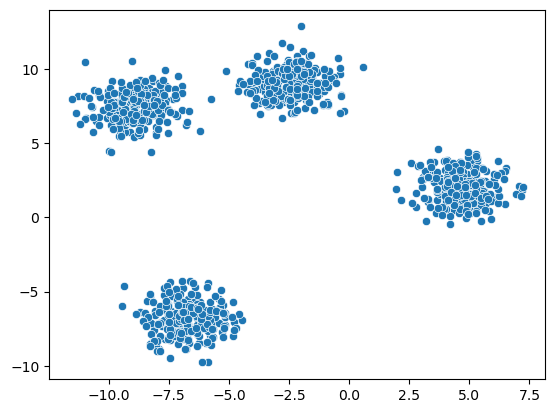

In [199]:
sns.scatterplot(x=x[:,0],y=x[:,1])

In [200]:
from sklearn.cluster import KMeans
k=4

In [201]:
kmeans=KMeans(n_clusters=k,
              random_state=42)

In [202]:
labels=kmeans.fit_predict(x)

In [203]:
import warnings
warnings.filterwarnings("ignore")

In [204]:
wcss=[]
for k in range(1,100):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(x)
    wcss.append(kmeans.inertia_)

<Axes: >

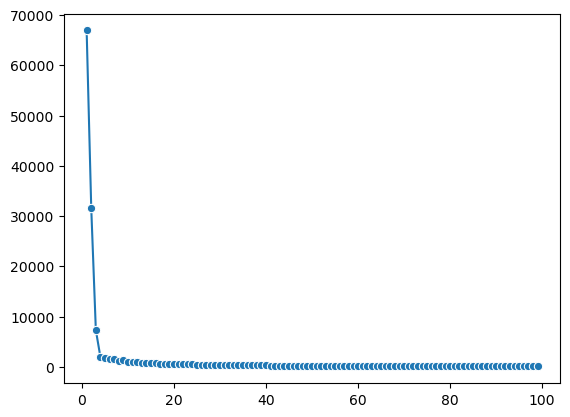

In [205]:
sns.lineplot(x=range(1,100),y=wcss,marker="o")

In [206]:
!pip install kneed

In [207]:
from kneed import KneeLocator

In [208]:
knee=KneeLocator(range(1,100),wcss,curve="convex",direction="decreasing")

In [209]:
print("optimal k= ",knee.elbow)

optimal k=  4


In [210]:
from sklearn.metrics import silhouette_score
ss=[]
for k in range(2,21):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(x)
    score=silhouette_score(x,labels)
    ss.append(score)
    

<Axes: >

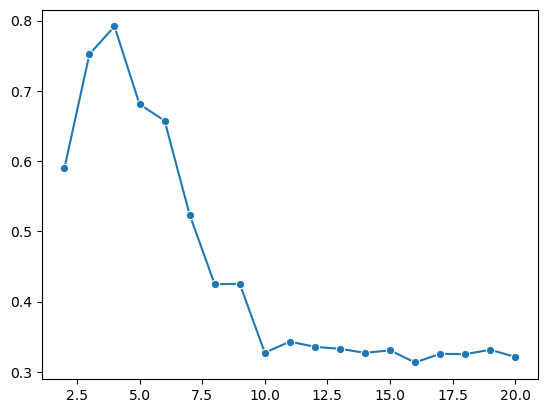

In [211]:
sns.lineplot(x=range(2,21),y=ss,marker="o")

In [212]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd


In [213]:
iris=load_iris()
x=iris.data
y=iris.target


<Axes: >

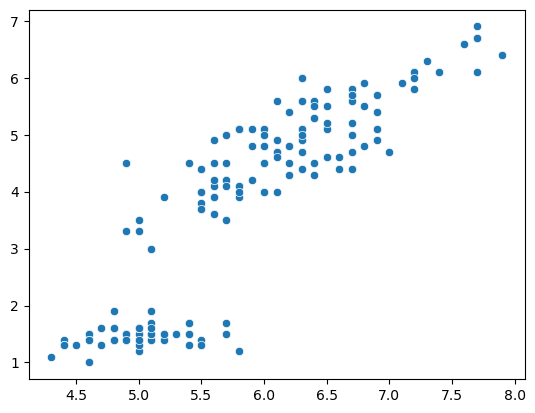

In [214]:
sns.scatterplot(x=x[:,0],y=x[:,2])

In [215]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [216]:
x_scaled=scaler.fit_transform(x)


In [217]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data=pca.fit_transform(x_scaled)

In [218]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
    

<Axes: >

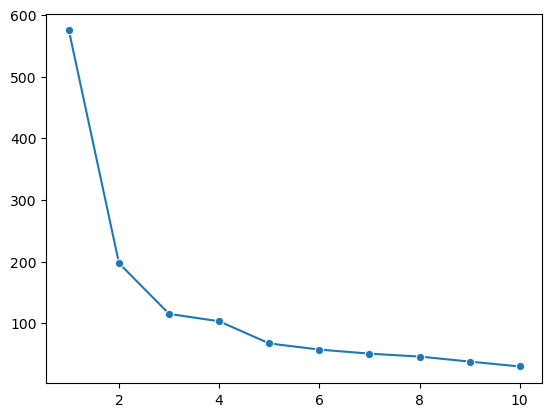

In [219]:
sns.lineplot(x=range(1,11),y=wcss,marker="o")

In [220]:
kmeans=KMeans(n_clusters=3,random_state=42)
labels=kmeans.fit_predict(pca_data)

<Axes: >

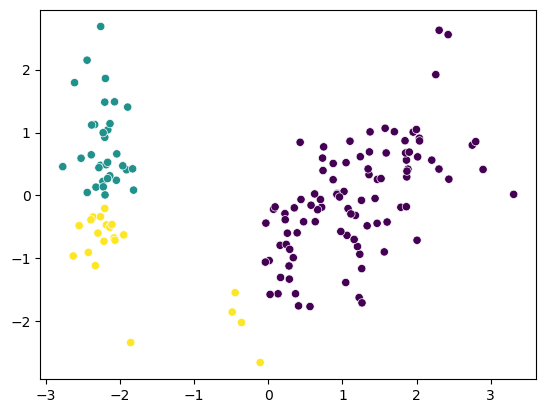

In [221]:
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)

<Axes: >

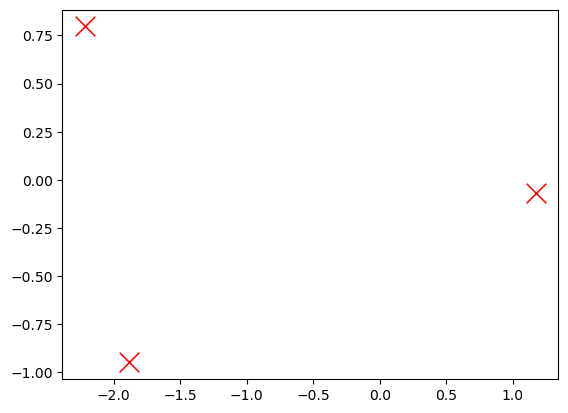

In [222]:
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker="x",c="red",s=200)

In [223]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [224]:
iris=load_iris()
x=iris.data
y=iris.target

In [225]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [226]:
from scipy.cluster.hierarchy import linkage,dendrogram

Text(0.5, 1.0, 'distance for hiierarchal clustering')

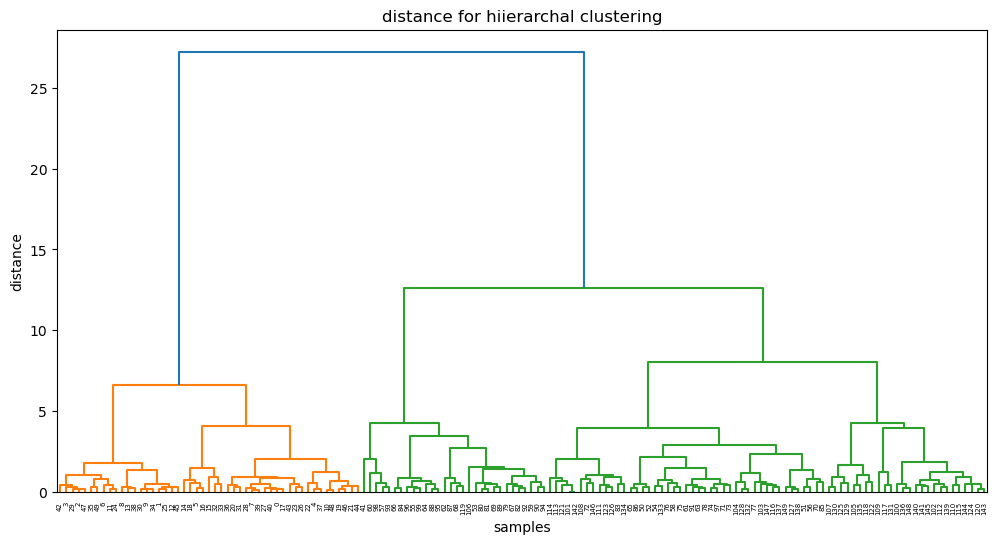

In [227]:
z=linkage(x_scaled,method="ward")
plt.figure(figsize=(12,6))
dendrogram(z)
plt.xlabel("samples")
plt.ylabel("distance")
plt.title("distance for hiierarchal clustering")

In [228]:
from sklearn.cluster import AgglomerativeClustering
agg=AgglomerativeClustering (n_clusters=2)
labels=agg.fit_predict(x_scaled)

<Axes: >

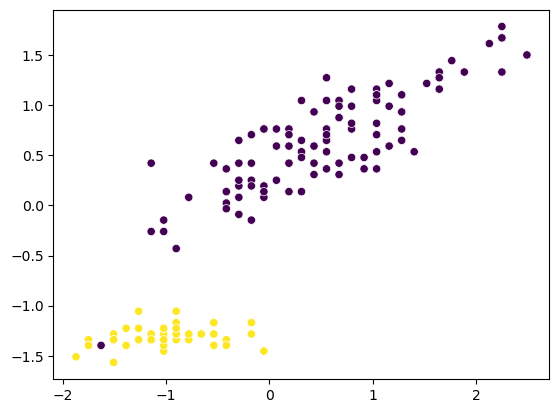

In [229]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)

In [230]:
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [231]:
iris=load_iris()
x=iris.data
y=iris.target

In [232]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

<Axes: >

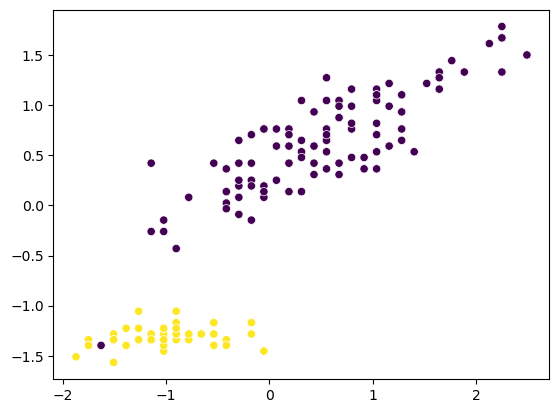

In [233]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)

<Axes: >

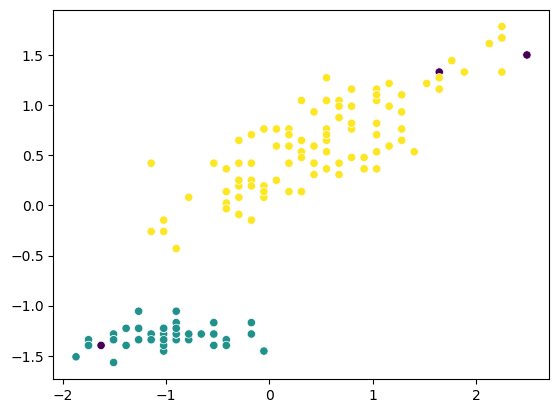

In [234]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.8,
              min_samples=5)
labels=dbscan.fit_predict(x_scaled)
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,2],c=labels)


In [235]:
from sklearn.datasets import make_moons
x,y=make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42)

In [236]:
x_scaled=scaler.fit_transform(x)

<Axes: >

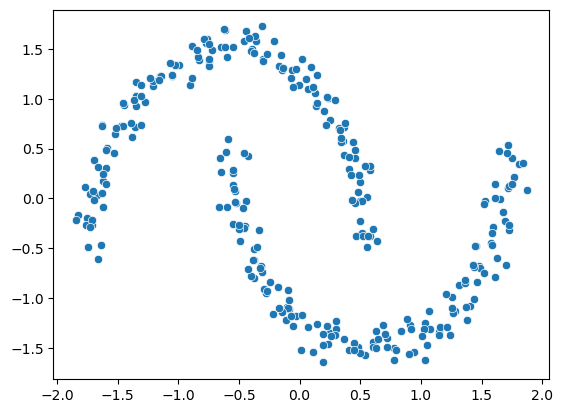

In [237]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1])

In [238]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=10,
              random_state=42)
labels=kmeans.fit_predict(x_scaled)

In [239]:
import warnings
warnings.filterwarnings("ignore")

<Axes: >

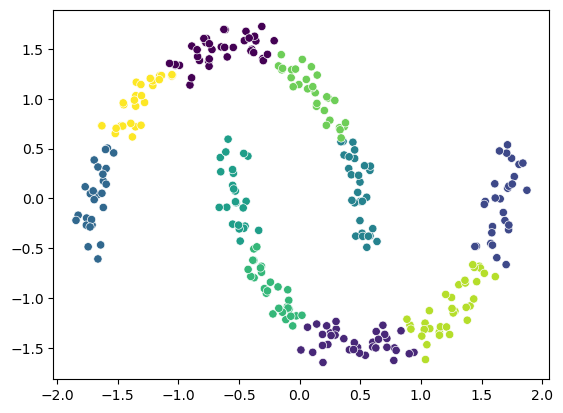

In [240]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

In [241]:
dbscan=DBSCAN(
    eps=0.5,
    min_samples=5)
labels=dbscan.fit_predict(x_scaled)

<Axes: >

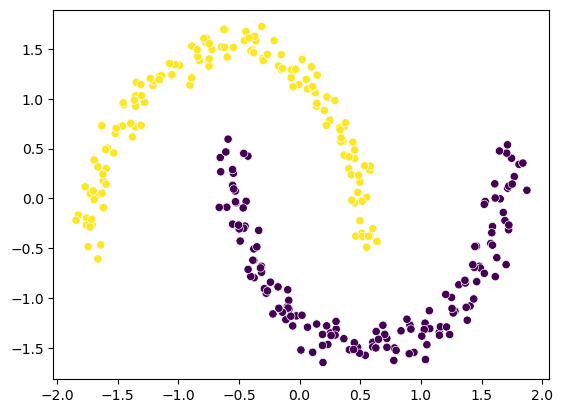

In [242]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

In [243]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [244]:
iris=load_iris()
x=pd.DataFrame(iris.data)
y=iris.target

In [245]:
x.shape

(150, 4)

In [246]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [247]:
x_scaled.reshape

<function ndarray.reshape>

In [248]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

In [249]:
x_pca.shape

(150, 2)

In [250]:
print("explained varaince ratio:",pca.explained_variance_ratio_)


explained varaince ratio: [0.72962445 0.22850762]


In [251]:
print(pca.components_)

[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


Text(0.5, 1.0, 'pca for iris dataset')

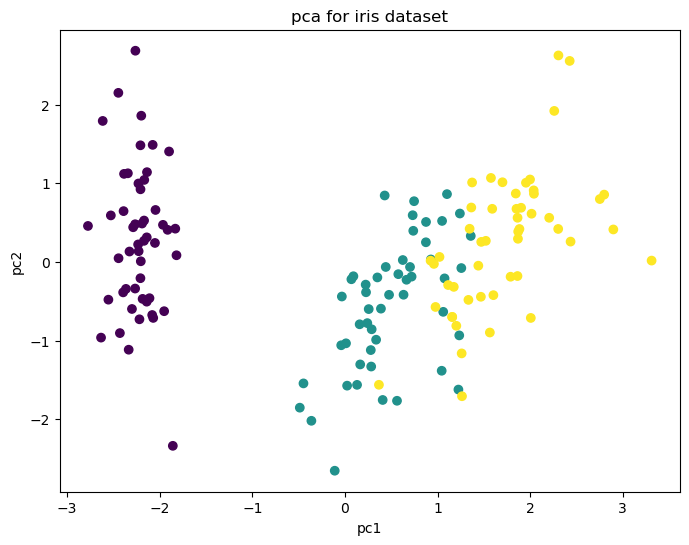

In [252]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],
            x_pca[:,1],
            c=y)
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pca for iris dataset")

In [253]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons


In [254]:
x,y=make_moons(
    n_samples=1000,
    noise=0.1,
    random_state=42)


In [255]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [256]:
x_scaled.shape

(1000, 2)

<Axes: >

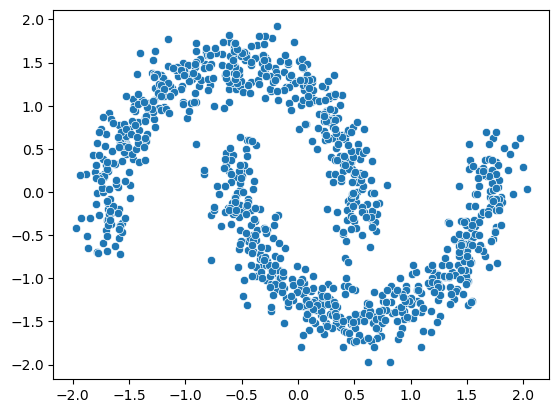

In [257]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1])

In [258]:
dbscan=DBSCAN(
    eps=0.18,
    min_samples=5)

In [259]:
labels=dbscan.fit_predict(x_scaled)

<Axes: >

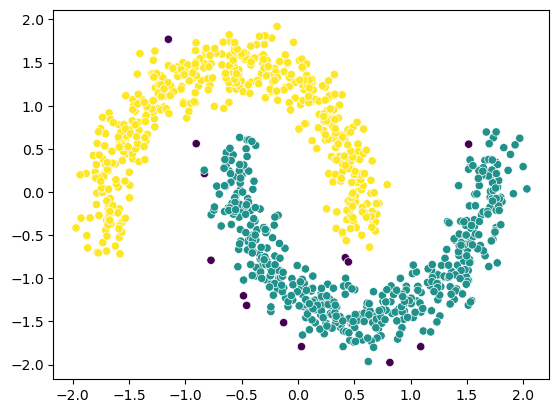

In [260]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

In [261]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [262]:
df=pd.read_csv("thyroid_dataset.csv")


In [263]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [264]:
df.shape

(6916, 22)

In [265]:
x=df.drop("Outlier_label",axis=1)
y=df["Outlier_label"]

In [266]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [267]:
from sklearn.neighbors import LocalOutlierFactor

In [268]:
neighbs=LocalOutlierFactor(contamination=0.036)

In [269]:
labels=neighbs.fit_predict(x_scaled)
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=labels)

In [270]:
import numpy as np
n_outliers=np.sum(labels==-1)
n_normal=np.sum(labels==1)
print("outliers:",n_outliers)
print("normal:",n_normal)

outliers: 249
normal: 6667


#unsupervised project

In [271]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [272]:
df=pd.read_csv("smartcart_customers.csv")

In [273]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [274]:
df.shape

(2240, 22)

In [275]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [276]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [277]:
df["Age"]=2026-df["Year_Birth"]

In [278]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()

In [279]:
df["customer_tenure_days"]=(reference_date-df["Dt_Customer"]).dt.days

In [280]:
df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntGoldProds"]

In [281]:
df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [282]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [283]:
df["Education"]=df["Education"].replace({
    "Basic":"undergraduate",
    "2n Cycle":"undergraduate",
    "Graduation":"graduate",
    "Master":"postgraduate",
    "PhD":"postgraduate"})

In [284]:
df["Education"].value_counts()

Education
graduate         1127
postgraduate      856
undergraduate     257
Name: count, dtype: int64

In [285]:
df["living_with"]=df["Marital_Status"].replace({
    "Married":"partner",
    "Together":"partner", 
   "Single":"alone",
   "Divorced":"alone", 
    "Widow":"alone",
    "Alone":"alone",
    "Absurd":"alone",
    "YOLO":"alone"})
    

In [286]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [287]:
df["living_with"].value_counts()

living_with
partner    1444
alone       796
Name: count, dtype: int64

In [288]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days', 'Total_Spending',
       'Total_Children', 'living_with'],
      dtype='object')

In [289]:
cols=['ID', 'Year_Birth', 'Marital_Status', 'Kidhome',
       'Teenhome', 'Dt_Customer']
spending_cols=[
        'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
cols_to_drop=cols+spending_cols
df_cleaned=df.drop(columns=cols_to_drop)

In [290]:
df_cleaned.shape

(2240, 15)

In [291]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,Total_Children,living_with
0,graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,alone
1,graduate,46344.0,38,2,1,1,2,5,0,0,72,113,26,2,alone
2,graduate,71613.0,26,1,8,2,10,4,0,0,61,312,755,0,partner
3,graduate,26646.0,26,2,2,0,4,6,0,0,42,139,50,1,partner
4,postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,395,1,partner


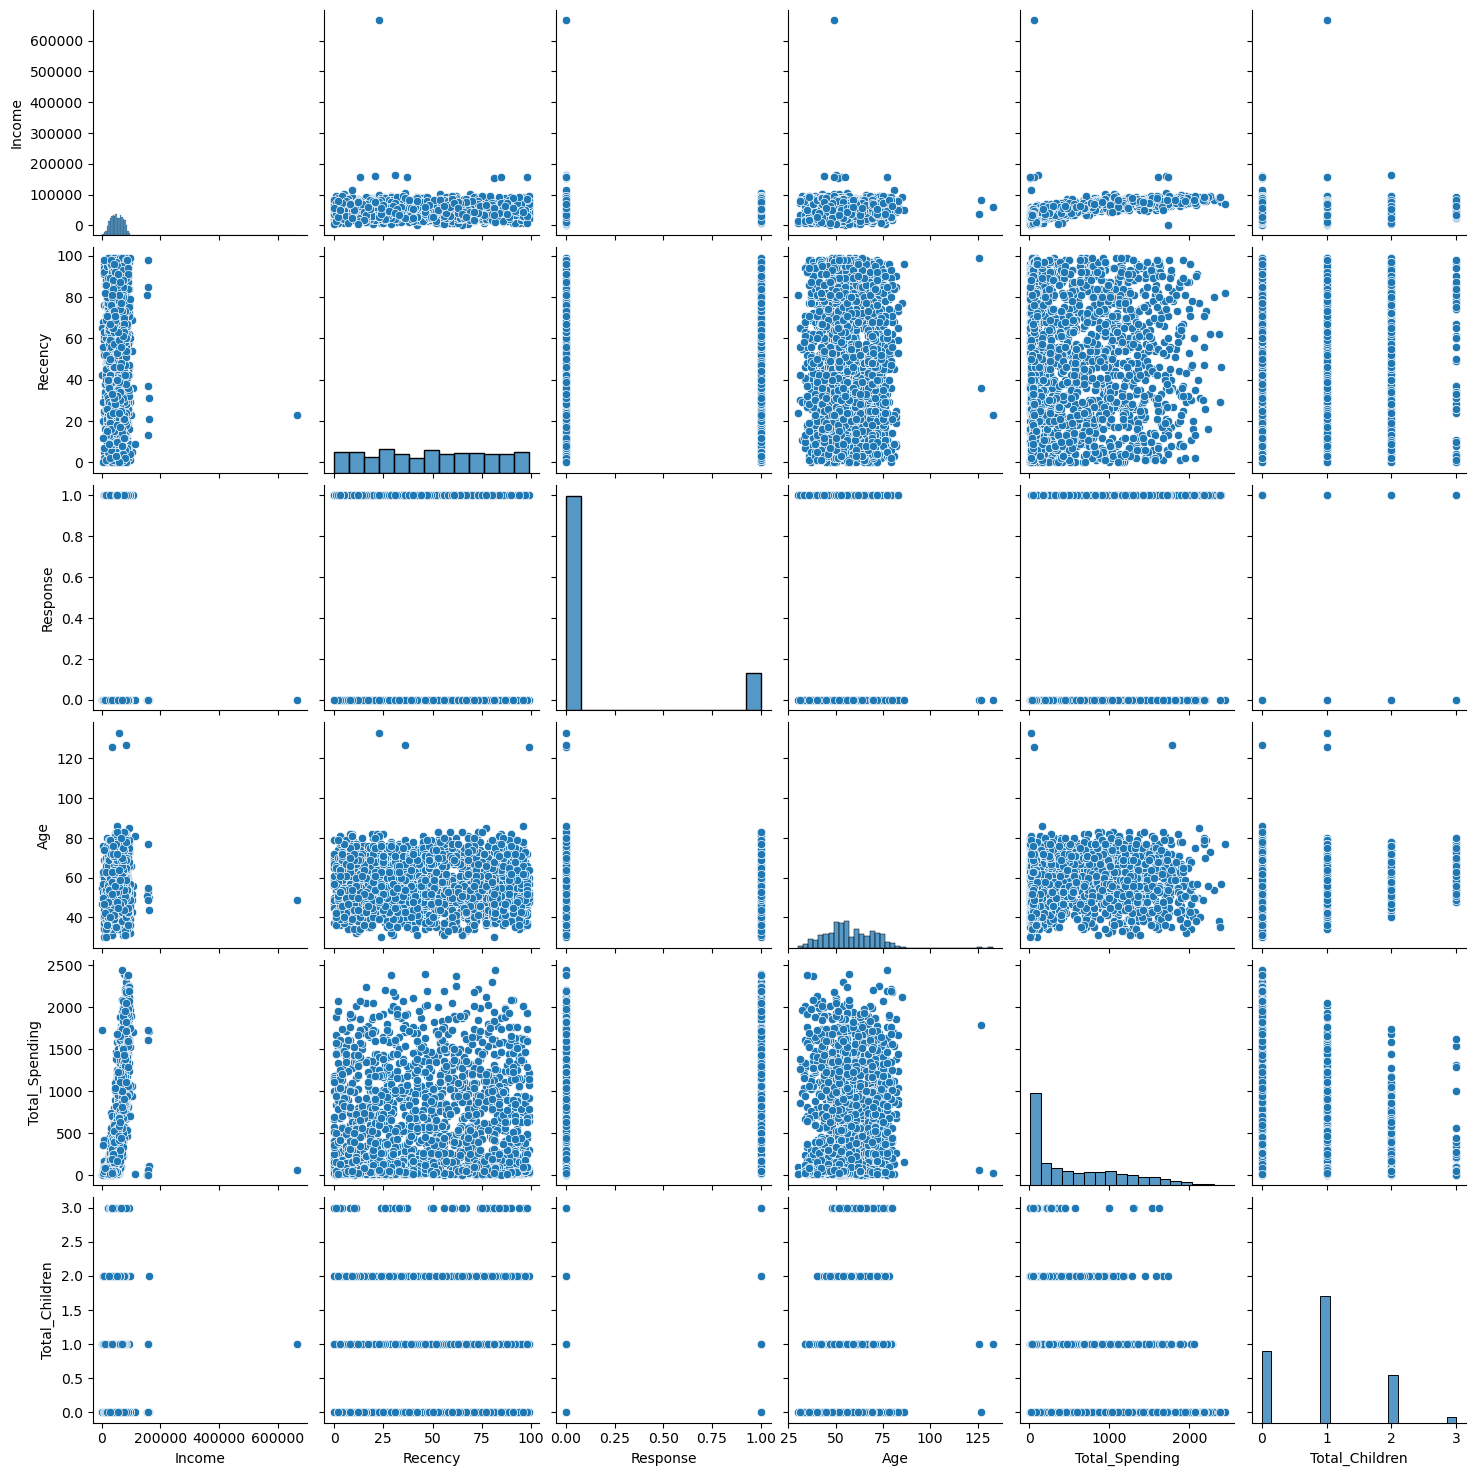

In [292]:
cols=["Income","Recency","Response","Age","Total_Spending","Total_Children"]
sns.pairplot(df_cleaned[cols])

In [293]:
print("data size with outliers:",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
print("data size with ouliers:",len(df_cleaned))


data size with outliers: 2240
data size with ouliers: 2236


<Axes: >

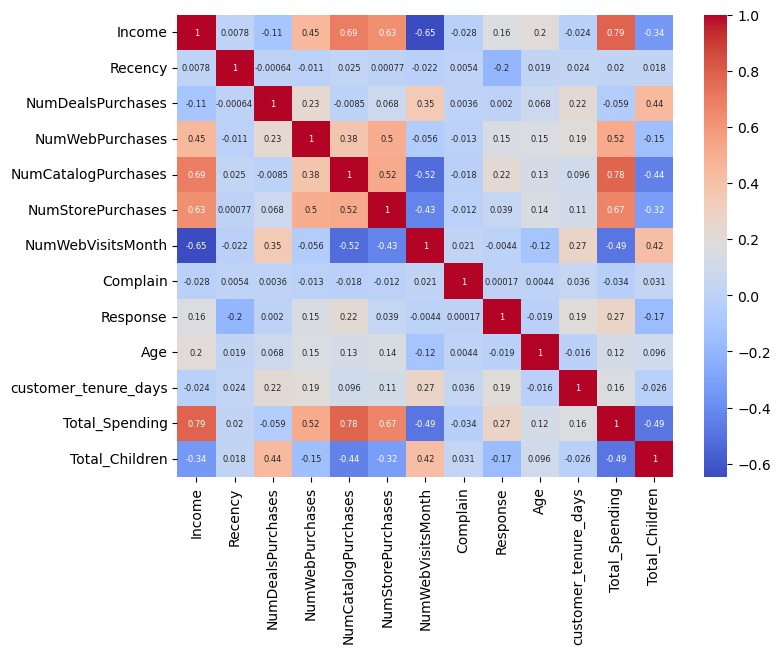

In [294]:
corr=df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm")

In [295]:
df_cleaned.shape

(2236, 15)

In [296]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cat_cols=["Education","living_with"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [297]:
enc_df=pd.DataFrame(enc_cols.toarray(),
columns=ohe.get_feature_names_out(cat_cols),
                    index=df_cleaned.index)
                    

In [298]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [299]:
df_encoded.shape

(2236, 18)

In [300]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,Total_Children,Education_graduate,Education_postgraduate,Education_undergraduate,living_with_alone,living_with_partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,26,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,755,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,50,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,395,1,0.0,1.0,0.0,0.0,1.0


In [301]:
from sklearn.preprocessing import StandardScaler
x=df_encoded
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [302]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
x_pca=pca.fit_transform(x_scaled)

In [303]:
pca.explained_variance_ratio_

array([0.23117348, 0.11385549, 0.10409073])

Text(0.5, 0, 'pca3')

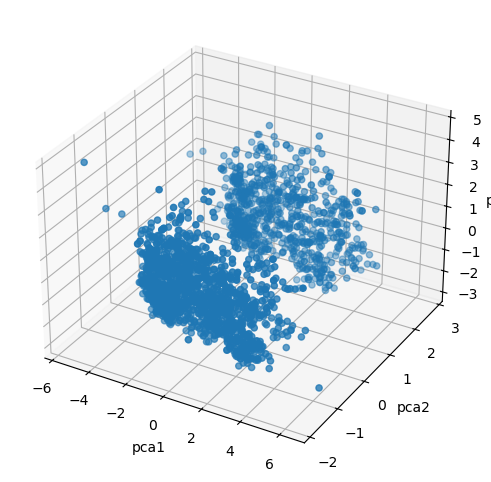

In [304]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")


In [305]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [306]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [307]:
optimal_k=knee.elbow
print("best k= ",optimal_k)


best k=  4


Text(0, 0.5, 'wcss')

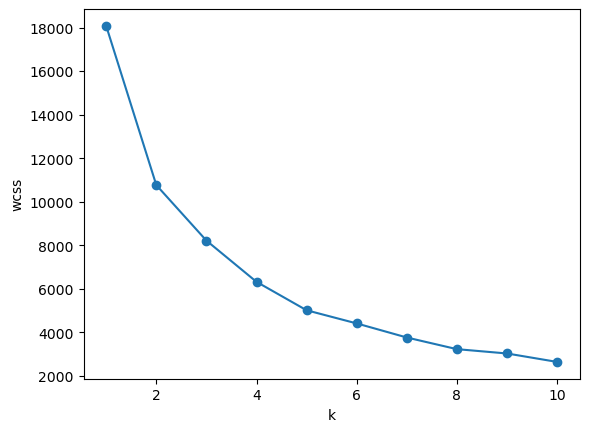

In [308]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("k")
plt.ylabel("wcss")

In [309]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(x_pca)
    score=silhouette_score(x_pca,labels)
    scores.append(score)

Text(0, 0.5, 'silhouette socre')

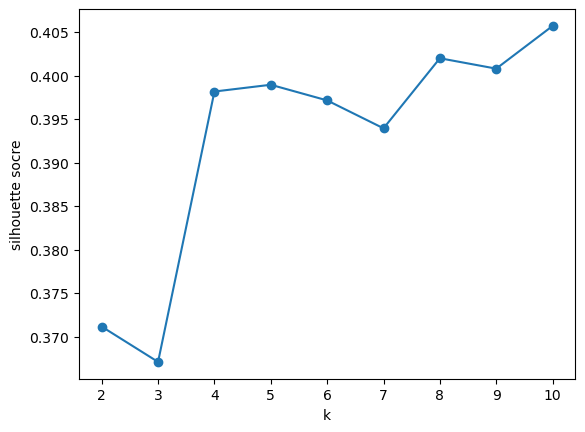

In [310]:
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("k")
plt.ylabel("silhouette socre")


Text(0, 0.5, 'ss')

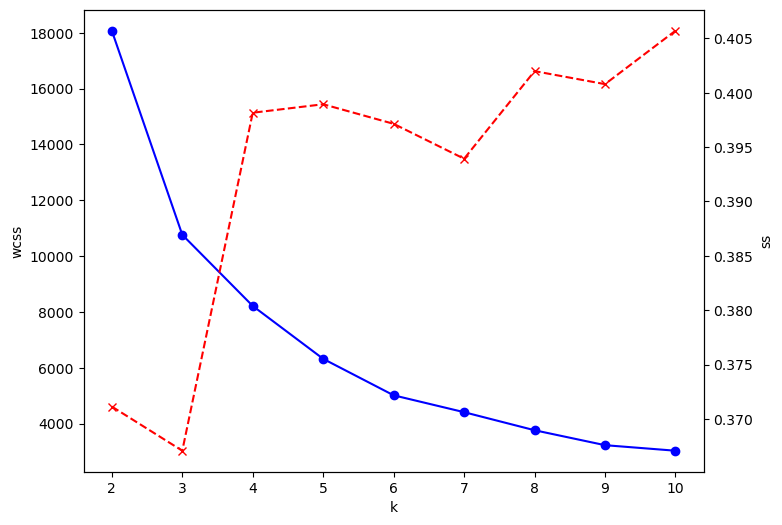

In [311]:
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("ss")

In [312]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(x_pca)


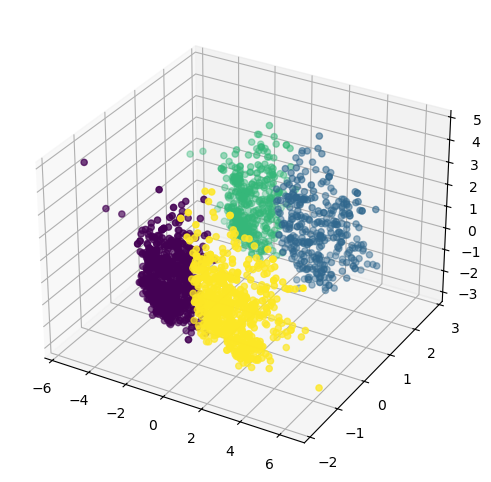

In [313]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels_kmeans)

In [314]:
from sklearn.cluster import AgglomerativeClustering
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels=agg_clf.fit_predict(x_pca)

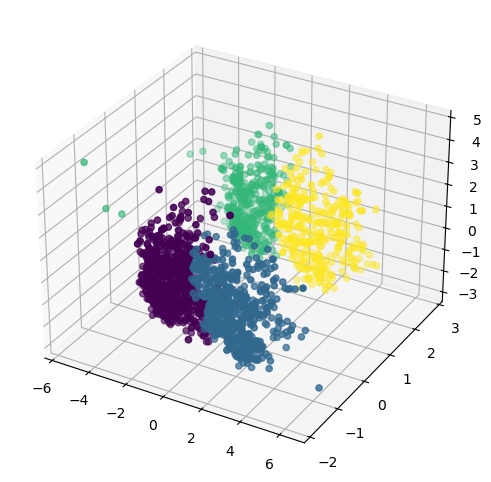

In [315]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c=labels)

In [316]:
x["cluster"]=labels
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Total_Spending,Total_Children,Education_graduate,Education_postgraduate,Education_undergraduate,living_with_alone,living_with_partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1529,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,26,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,755,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,50,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,395,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

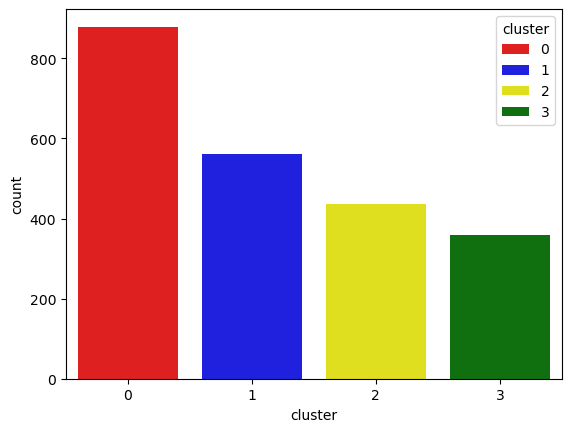

In [317]:
pal=["red","blue","yellow","green"]
sns.countplot(x=x["cluster"],palette=pal,hue=x["cluster"])

MACHINE LEARNING

In [318]:
import pandas as pd
import seaborn as sns
insurance_data=pd.read_csv("insurance_csv.csv")
insurance_data


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

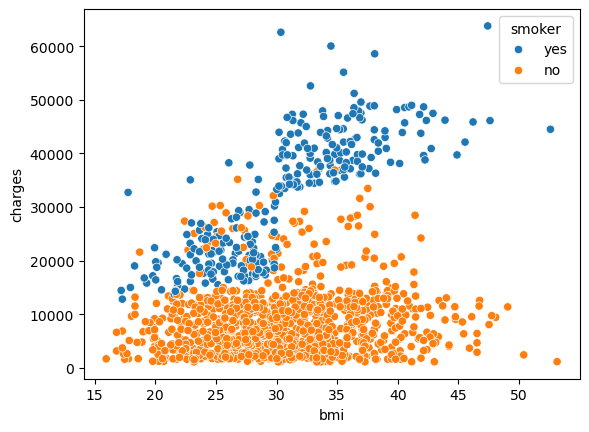

In [319]:
sns.scatterplot(x=insurance_data["bmi"],y=insurance_data["charges"],hue=insurance_data["smoker"])

In [320]:
x=insurance_data.drop(columns=["charges","region"])
y=insurance_data["charges"]
x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes":1,"no":0})
x.head()

,age,sex,bmi,children,smoker
0,19,1,27.900,0,1
1,18,0,33.770,1,0
2,28,0,33.000,3,0
3,33,0,22.705,0,0
4,32,0,28.880,0,0


In [321]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_test.head()

,age,sex,bmi,children,smoker
764,45,1,25.175,2,0
887,36,1,30.020,0,0
890,64,1,26.885,0,1
1293,46,0,25.745,3,0
259,19,0,31.920,0,1


In [322]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [323]:
y_test

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64

In [324]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print(r2)
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
print(adjusted_r2)

0.7811302113434095
0.7769533069797342
